# Feature Selection using MRMR - all and 40 Derived features both!

In [1]:
import core.constants as c
from core.utils import save_df_as_table_image, extract_subject_id
import os

import warnings

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from feature_engine.selection import SmartCorrelatedSelection
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedGroupKFold

from feature_engine.selection import MRMR

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
SAVE_DATA = True

In [ ]:
# Base features no extensive outlier treatment.
data = pd.read_csv(c.RICKD_FEATURE_SELECTION_PART_2_DATA_FILE_2, index_col=0)
display(data.head())

data.info(verbose=True)

,age,height,weight,gender,is_injured,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,...,dom_leg_stride_length,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,47.0,172.0,61.9,female,True,24.591474,1.552075,-6.336418,1.187877,-1.522192,...,1.891817,0.000000,78.947368,0.000000,61,-3,0.435,0.0150,96.433793,3.847659
100002_20110601T140505,37.0,173.4,70.6,male,True,24.830009,-1.873425,-4.949355,3.761674,-10.091984,...,2.001175,0.000000,81.632653,0.000000,52,23,0.445,0.0250,86.521432,-8.424086
100003_20110601T095930,51.0,186.0,86.5,male,True,25.603645,1.020660,-9.918405,2.724571,-9.056648,...,2.241927,0.000000,78.947368,0.000000,46,-14,0.445,-0.0025,76.611379,-6.069608
100004_20110203T120721,35.0,175.6,59.0,male,True,24.519444,-1.488008,-9.005590,-1.513753,-3.335102,...,1.962250,0.000000,82.191781,0.000000,44,-8,0.440,-0.0200,92.593339,9.320156
100004_20140929T102035,39.0,175.0,61.0,male,False,24.876986,-1.453904,-12.937424,-4.962587,-11.353953,...,2.108590,-0.014643,83.333333,0.574713,43,-4,0.420,-0.0100,87.481400,12.389611


<class 'pandas.core.frame.DataFrame'>
Index: 1813 entries, 100001_20110531T161051 to 201225_20140515T133244
Data columns (total 84 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    1812 non-null   float64
 1   height                                 1805 non-null   float64
 2   weight                                 1808 non-null   float64
 3   gender                                 1812 non-null   object 
 4   is_injured                             1813 non-null   bool   
 5   dom_leg_ankle_df_peak_angle            1813 non-null   float64
 6   dom_leg_diff_ankle_df_peak_angle       1813 non-null   float64
 7   dom_leg_ankle_eve_excursion            1813 non-null   float64
 8   dom_leg_diff_ankle_eve_excursion       1813 non-null   float64
 9   dom_leg_ankle_eve_peak_angle           1813 non-null   float64
 10  dom_leg_diff_ankle_eve_peak_angle     

In [4]:
from core.evaluation import standardise_and_split
from core.utils import extract_subject_id

y_label = "is_injured"
y = data[y_label]
X = data.drop(columns=[y_label])

feature_categorical_columns = ["gender"]

(result, pipeline) = standardise_and_split(
    X, y, groups=extract_subject_id(X.index.to_series()),
    feature_categorical_columns=feature_categorical_columns,
    test_size=0.2, val_size=0.1,
    return_pipeline=True,
)

(X_train, X_val, X_test,
 y_train, y_val, y_test,
 groups_train, groups_val, groups_test) = result

(imputer, preprocessing) = pipeline

print("X_train.shape: ", X_train.shape)
print("y_train.shape: ", y_train.shape)
print("X_val.shape: ", X_val.shape)
print("y_val.shape: ", y_val.shape)
print("X_test.shape: ", X_test.shape)
print("y_test.shape: ", y_test.shape)
print("groups_train.shape: ", groups_train.shape)
print("groups_val.shape: ", groups_val.shape)
print("groups_test.shape: ", groups_test.shape)
print(50*"=")
print("Class distribution: Train:", y_train.value_counts().to_dict(), "Percentage:", (y_train.value_counts() / y_train.shape[0] * 100).to_dict())
print("Class distribution: Val:", y_val.value_counts().to_dict(), "Percentage:", (y_val.value_counts() / y_val.shape[0] * 100).to_dict())
print("Class distribution: Test:", y_test.value_counts().to_dict(), "Percentage:", (y_test.value_counts() / y_test.shape[0] * 100).to_dict())

X_train.shape:  (1254, 84)
y_train.shape:  (1254,)
X_val.shape:  (192, 84)
y_val.shape:  (192,)
X_test.shape:  (367, 84)
y_test.shape:  (367,)
groups_train.shape:  (1254,)
groups_val.shape:  (192,)
groups_test.shape:  (367,)
Class distribution: Train: {True: 803, False: 451} Percentage: {True: 64.03508771929825, False: 35.96491228070175}
Class distribution: Val: {True: 124, False: 68} Percentage: {True: 64.58333333333334, False: 35.41666666666667}
Class distribution: Test: {True: 224, False: 143} Percentage: {True: 61.03542234332425, False: 38.96457765667575}


In [ ]:
# Save
if SAVE_DATA:
    X_train.to_csv(c.RICKD_MODEL_1_X_TRAIN_DERIVED_STANDARDISED)
    y_train.to_csv(c.RICKD_MODEL_1_Y_TRAIN_DERIVED_STANDARDISED)
    X_test.to_csv(c.RICKD_MODEL_1_X_TEST_DERIVED_STANDARDISED)
    y_test.to_csv(c.RICKD_MODEL_1_Y_TEST_DERIVED_STANDARDISED)
    X_val.to_csv(c.RICKD_MODEL_1_X_VAL_DERIVED_STANDARDISED)
    y_val.to_csv(c.RICKD_MODEL_1_Y_VAL_DERIVED_STANDARDISED)

In [ ]:
# Read
if not SAVE_DATA:
    X_train = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_DERIVED_STANDARDISED, index_col=0)
    y_train = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_DERIVED_STANDARDISED, index_col=0)

    X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_DERIVED_STANDARDISED, index_col=0)
    y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_DERIVED_STANDARDISED, index_col=0)

    X_val = pd.read_csv(c.RICKD_MODEL_1_X_VAL_DERIVED_STANDARDISED, index_col=0)
    y_val = pd.read_csv(c.RICKD_MODEL_1_Y_VAL_DERIVED_STANDARDISED, index_col=0)

In [7]:
# We want stable importance ranking:
# We want enough complexity to capture non-linear relationships.
# We want enough randomness so feature importances aren’t biased toward high-cardinality variables.
# We want parameters that avoid overfitting
param_grid = {
    "n_estimators": [500],  # More provides more stability.
    "max_depth": [5, 10], 
    "min_samples_leaf": [2, 5, 8],
    "max_features": ["sqrt", "log2"],  # Give smaller features a chance to be selected
    "min_samples_split": [4, 10, 16],  # Proportional to min_samples_leaf
    "bootstrap": [True]  # So each tree sees a slightly different dataset
}

sel = MRMR( 
        method="RFCQ",
        scoring="roc_auc",
        param_grid = param_grid,
        cv=3,
        regression=False,
        max_features=40,
        random_state=RANDOM_STATE,
    )
sel.fit(X_train, y_train)

MRMR(max_features=40, method='RFCQ',
     param_grid={'bootstrap': [True], 'max_depth': [5, 10],
                 'max_features': ['sqrt', 'log2'],
                 'min_samples_leaf': [2, 5, 8],
                 'min_samples_split': [4, 10, 16], 'n_estimators': [500]},
     random_state=42)

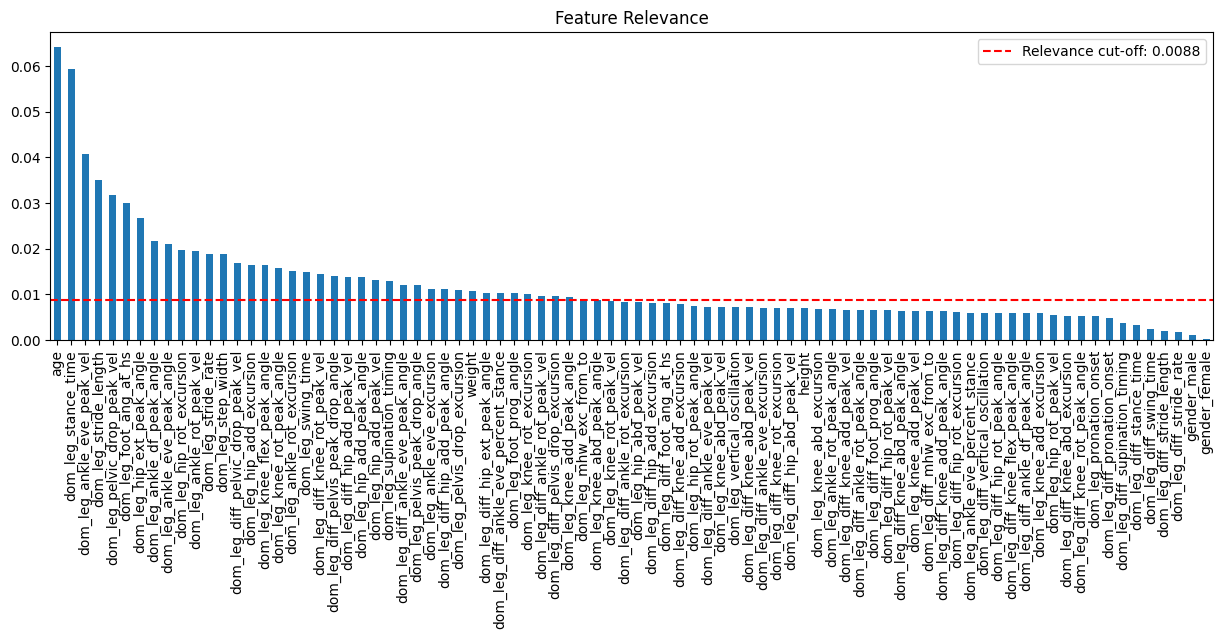

In [8]:
relevance_cutoff = sorted(sel.relevance_, reverse=True)[39]
ax = pd.Series(sel.relevance_, index=sel.variables_).sort_values(
    ascending=False).plot.bar(figsize=(15, 4))
plt.axhline(relevance_cutoff, color='red', linestyle='--', label=f'Relevance cut-off: {relevance_cutoff:.4f}')
plt.title("Feature Relevance")
plt.legend()
plt.show()

In [9]:
sorted_vars = sorted(zip(sel.variables_, sel.relevance_), key=lambda x: x[1], reverse=True)
for i, (var, rel) in enumerate(sorted_vars):
    print(f"{i}: {var}: {rel}")

0: age: 0.06422937311514863
1: dom_leg_stance_time: 0.059215979591078945
2: dom_leg_ankle_eve_peak_vel: 0.040597923892731216
3: dom_leg_stride_length: 0.034999899651154284
4: dom_leg_pelvic_drop_peak_vel: 0.03169035007581468
5: dom_leg_foot_ang_at_hs: 0.02989942900120328
6: dom_leg_hip_ext_peak_angle: 0.02678099791349953
7: dom_leg_ankle_df_peak_angle: 0.02168135725490408
8: dom_leg_ankle_eve_peak_angle: 0.02101174665997724
9: dom_leg_hip_rot_excursion: 0.019619591045144193
10: dom_leg_ankle_rot_peak_vel: 0.019549132299518848
11: dom_leg_stride_rate: 0.018738889782323503
12: dom_leg_step_width: 0.018730755594735724
13: dom_leg_diff_pelvic_drop_peak_vel: 0.01688989754060283
14: dom_leg_hip_add_excursion: 0.016430500863898693
15: dom_leg_knee_flex_peak_angle: 0.016323770766652246
16: dom_leg_knee_rot_peak_angle: 0.01572065698205371
17: dom_leg_ankle_rot_excursion: 0.01509924919132438
18: dom_leg_swing_time: 0.014961752474569226
19: dom_leg_diff_knee_rot_peak_vel: 0.014538131026966345
20:

In [ ]:
print("="*30)
print("X Train with 40 selected features")
print("="*30)
X_train_sel = sel.transform(X_train)
display(X_train_sel.head())
print(X_train_sel.info(verbose=True))

print("\n="*30)
print("X Test with 40 selected features")
print("="*30)
X_test_sel = sel.transform(X_test)
display(X_test_sel.head())
print(X_test_sel.info(verbose=True))

print("\n="*30)
print("X Val with 40 selected features")
print("="*30)
X_val_sel = sel.transform(X_val)
display(X_val_sel.head())
print(X_val_sel.info(verbose=True))

X_train_sel.to_csv(c.RICKD_MODEL_1_Y_TRAIN_DERIVED_STANDARDISED_40)
X_test_sel.to_csv(c.RICKD_MODEL_1_X_TEST_DERIVED_STANDARDISED_40)
X_val_sel.to_csv(c.RICKD_MODEL_1_X_VAL_DERIVED_STANDARDISED_40)

X Train with 40 selected features


,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_diff_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.714694,-0.639845,1.051370,1.454647,0.472507,1.321747,-0.223068,-0.781733,0.359592,0.476919,...,-0.974647,1.622559,1.799970,0.738134,2.028758,-0.275493,-0.853122,0.545041,0.186132,0.357728
100003_20110601T095930,1.042651,1.266247,1.347072,-0.662812,-0.050007,-0.078608,-1.854768,-0.112852,-0.707250,0.662012,...,-0.453087,-0.431800,-0.081734,0.586728,1.207229,0.854784,-0.853122,-0.946625,0.438877,-0.789593
100004_20110203T120721,-0.269179,-0.864547,1.030327,0.945153,0.177702,-0.228718,-0.331848,-0.132397,0.042685,0.437973,...,-0.477555,1.566663,1.685412,-0.170302,-1.490864,-0.048113,-0.213159,-1.145514,0.312504,0.990836
100004_20140929T102035,0.058779,-0.709580,1.134781,-1.308439,-0.191265,-0.954770,0.212052,-0.688086,-0.154535,0.513911,...,1.012003,1.666818,1.543174,0.132510,-0.937232,0.424326,0.012013,-1.244959,-0.192985,1.345939
100006_20110209T104505,0.222757,0.840089,0.479362,0.807233,1.797945,-0.258182,0.320832,0.537560,0.065560,-0.428043,...,2.191623,-0.391955,-1.007547,-0.775925,1.018287,0.146637,0.726689,-1.046070,-0.066612,-0.114763


<class 'pandas.core.frame.DataFrame'>
Index: 1254 entries, 100001_20110531T161051 to 201225_20140515T133244
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    1254 non-null   float64
 1   weight                                 1254 non-null   float64
 2   dom_leg_ankle_df_peak_angle            1254 non-null   float64
 3   dom_leg_ankle_eve_peak_angle           1254 non-null   float64
 4   dom_leg_diff_ankle_eve_peak_angle      1254 non-null   float64
 5   dom_leg_ankle_eve_peak_vel             1254 non-null   float64
 6   dom_leg_diff_ankle_eve_percent_stance  1254 non-null   float64
 7   dom_leg_ankle_rot_excursion            1254 non-null   float64
 8   dom_leg_diff_ankle_rot_excursion       1254 non-null   float64
 9   dom_leg_ankle_rot_peak_vel             1254 non-null   float64
 10  dom_leg_foot_ang_at_hs                

,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_diff_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100005_20110208T120837,-0.433158,-1.019514,0.626752,-0.120337,-0.551621,0.650768,-0.658188,-0.183554,-0.444235,0.267743,...,-0.525354,0.538745,0.369887,-0.321707,-0.372110,-0.689584,1.643221,-1.443848,-1.456708,-0.369382
100009_20110302T140353,-0.515147,-1.716864,-0.176740,1.097575,1.143979,0.491948,0.429612,-0.992972,-0.160994,-0.997620,...,0.387088,2.446867,2.582438,0.132510,0.588883,-0.602270,-0.044669,0.743930,-0.066612,-0.533482
100015_20110329T121446,1.862545,1.614923,1.617182,0.636517,0.752657,0.857833,-0.875748,0.238206,0.422985,0.834426,...,-1.929336,-0.707624,-0.634760,1.646570,1.195182,-0.038444,-1.538700,0.545041,0.438877,1.406794
100024_20110419T164319,1.206630,0.375188,0.153072,0.450931,0.038082,-0.798254,0.320832,-0.908278,0.575575,-0.425447,...,0.889035,-0.287030,-0.429970,0.738134,1.002312,-1.635452,-0.101350,0.644486,-0.698474,1.092714
100030_20110505T115803,0.878672,1.289492,1.273711,-0.459982,0.395464,1.601274,-0.005508,0.008546,0.410579,0.536747,...,0.681745,1.174095,1.197576,1.116649,1.938175,-0.840759,-0.853122,0.942819,-0.066612,0.596135


<class 'pandas.core.frame.DataFrame'>
Index: 367 entries, 100005_20110208T120837 to 201223_20140415T132359
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    367 non-null    float64
 1   weight                                 367 non-null    float64
 2   dom_leg_ankle_df_peak_angle            367 non-null    float64
 3   dom_leg_ankle_eve_peak_angle           367 non-null    float64
 4   dom_leg_diff_ankle_eve_peak_angle      367 non-null    float64
 5   dom_leg_ankle_eve_peak_vel             367 non-null    float64
 6   dom_leg_diff_ankle_eve_percent_stance  367 non-null    float64
 7   dom_leg_ankle_rot_excursion            367 non-null    float64
 8   dom_leg_diff_ankle_rot_excursion       367 non-null    float64
 9   dom_leg_ankle_rot_peak_vel             367 non-null    float64
 10  dom_leg_foot_ang_at_hs                 

,age,weight,dom_leg_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_ankle_rot_excursion,dom_leg_diff_ankle_rot_excursion,dom_leg_ankle_rot_peak_vel,...,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_pelvis_peak_drop_angle,dom_leg_diff_pelvis_peak_drop_angle,dom_leg_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_stride_rate,dom_leg_supination_timing,dom_leg_swing_time,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100002_20110601T140505,-0.105200,0.034261,1.121057,-0.953779,-0.169985,0.766038,0.538392,1.298036,0.299303,1.375747,...,0.264104,1.408227,1.535461,-0.170302,-0.814664,0.077551,-0.323448,-0.349959,0.438877,-1.061981
100013_20110323T140900,0.386736,-0.058719,0.496984,-0.324490,0.674224,0.432200,0.429612,0.229896,0.092708,0.761415,...,1.225558,0.557593,1.575418,-0.321707,1.435872,0.374079,0.126961,0.047819,-0.066612,-1.232945
100022_20110418T115212,-1.417030,-0.895540,1.020740,-0.570357,-0.097279,-1.448934,0.755952,-1.556849,-0.131216,-1.522676,...,0.846211,-0.701233,-0.282955,-1.230143,-0.798738,0.536816,0.012013,0.644486,0.944366,-0.126304
100034_20110525T141002,0.304747,-0.004481,0.535857,1.683211,1.695295,0.903621,-0.114288,-0.874754,-0.234505,-1.235243,...,0.139223,0.199025,-0.036927,-0.775925,-1.942342,0.174585,-0.539583,-1.742181,1.197110,0.618952
100054_20110622T135245,-0.679126,1.289492,1.186713,0.293009,-0.615511,0.442661,0.266442,1.280099,-0.158018,1.424168,...,0.445017,-0.132991,-0.004906,-0.018896,2.101479,0.163755,-0.432246,-0.648292,0.438877,1.810952


<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 100002_20110601T140505 to 201224_20140417T141711
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    192 non-null    float64
 1   weight                                 192 non-null    float64
 2   dom_leg_ankle_df_peak_angle            192 non-null    float64
 3   dom_leg_ankle_eve_peak_angle           192 non-null    float64
 4   dom_leg_diff_ankle_eve_peak_angle      192 non-null    float64
 5   dom_leg_ankle_eve_peak_vel             192 non-null    float64
 6   dom_leg_diff_ankle_eve_percent_stance  192 non-null    float64
 7   dom_leg_ankle_rot_excursion            192 non-null    float64
 8   dom_leg_diff_ankle_rot_excursion       192 non-null    float64
 9   dom_leg_ankle_rot_peak_vel             192 non-null    float64
 10  dom_leg_foot_ang_at_hs                 